Análise exploratória dos datasets de features extraídas.

Objetivos:
- Verificar integridade dos dados (nulls, constantes, tipos)
- Distribuição de labels por dataset e por sujeito
- Distribuição das features (histogramas, boxplots)
- Separação entre classes (features por label)
- Correlação entre features

Datasets:
- dataset_stress.csv     -> Cenário 1 (REST vs STRESS)
- dataset_anaerobic.csv  -> Protocolo anaeróbico
- dataset_aerobic.csv    -> Protocolo aeróbico

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys
PROJECT_ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR

sns.set_theme(style="whitegrid")

Carrega os três datasets e exibe shape, tipos e verificação de nulos/constantes.


In [ ]:
datasets = {}
for name in ['stress', 'anaerobic', 'aerobic']:
    path = PROCESSED_DIR / f"dataset_{name}.csv"
    if path.exists():
        datasets[name] = pd.read_csv(path)

# Colunas de metadados vs features
META_COLS = ['subject_id', 'window_id', 'label', 'protocol']

for name, df in datasets.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    n_nulls = df[feat_cols].isnull().sum().sum()
    n_const = sum(df[c].std() == 0 for c in feat_cols)
    
    print(f"{name.upper()}")
    print(f"  - Shape: {df.shape}")
    print(f"  - Sujeitos: {df['subject_id'].nunique()}")
    print(f"  - Features: {len(feat_cols)}")
    print(f"  - Nulls: {n_nulls}")
    print(f"  - Features constantes (std=0): {n_const}")
    print(f"  - Labels: {df['label'].value_counts().to_dict()}")


=== STRESS ===
  Shape: (2210, 52)
  Sujeitos: 31
  Features: 49
  Nulls: 0
  Features constantes (std=0): 0
  Labels: {0: 1161, 1: 1049}

=== ANAEROBIC ===
  Shape: (1544, 53)
  Sujeitos: 29
  Features: 49
  Nulls: 0
  Features constantes (std=0): 0
  Labels: {0: 1455, 1: 89}

=== AEROBIC ===
  Shape: (1967, 53)
  Sujeitos: 27
  Features: 49
  Nulls: 0
  Features constantes (std=0): 0
  Labels: {1: 1190, 0: 777}



Visualiza o balanceamento REST/STRESS (ou REST/EXERCÍCIO) por sujeito.
Sujeitos com desbalanceamento extremo podem dominar o treinamento
se não houver GroupKFold ou estratificação.

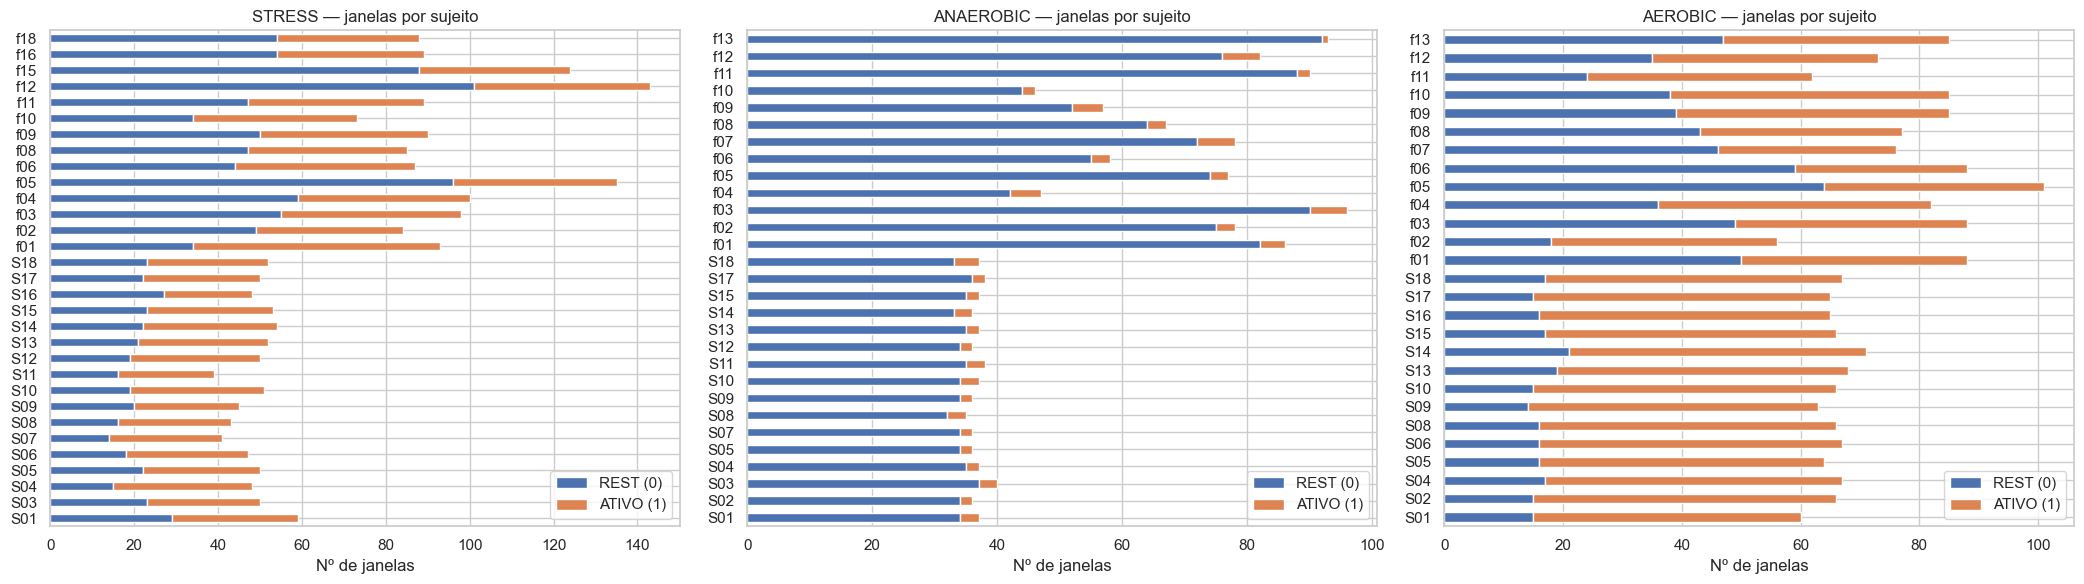

In [ ]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 6))
if len(datasets) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, datasets.items()):
    pivot = df.groupby(['subject_id', 'label']).size().unstack(fill_value=0)
    pivot.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f"{name.upper()} janelas por sujeito")
    ax.set_xlabel("Numero de janelas")
    ax.set_ylabel("Sujeitos")
    ax.legend(['REST (0)', 'ATIVO (1)'], loc='lower right')

plt.tight_layout()
plt.show()

Describe das features numéricas para cada dataset, com foco em identificar: escalas muito diferentes entre features que necessitam de
normalização, distribuições com caudas longas, e features com range muito estreito que tem pouco poder discriminativo.

In [ ]:
for name, df in datasets.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    print(f"=== {name.upper()} ===")
    print(df[feat_cols].describe().round(4).to_string())
    print()

=== STRESS ===
        bvp_mean    bvp_std  acc_x_mean  acc_x_std  acc_y_mean  acc_y_std  acc_z_mean  acc_z_std   acc_mean    acc_std  acc_ratio_up  acc_ratio_down  mean_raw_eda  std_raw_eda  mean_tonic_eda  std_tonic_eda  tonic_ratio_up  tonic_ratio_down  mean_phasic_eda  std_phasic_eda  peaks_density  scr_mean_amp  scr_mean_height  scr_mean_risetime  scr_mean_recoverytime    hr_mean     hr_std  hr_ratio_up  hr_ratio_down    max_ibi    min_ibi   mean_ibi  hr_mean_ibi      pnn20      pnn50      rmssd       sdnn  total_power      ratio  VLF_power   VLF_peak   LF_power    LF_peak       LF_n   HF_power    HF_peak       HF_n  VHF_power   VHF_peak
count  2210.0000  2210.0000   2210.0000  2210.0000   2210.0000  2210.0000   2210.0000  2210.0000  2210.0000  2210.0000     2210.0000       2210.0000     2210.0000    2210.0000       2210.0000      2210.0000       2210.0000         2210.0000        2210.0000       2210.0000      2210.0000     2210.0000        2210.0000          2210.0000           

Distribuição de cada feature no dataset de stress.
Features com distribuição bimodal tem uma tendencia de indicar boa separação entre classes.
Features com distribuição muito concentrada, ou seja com pico estreito, têm pouca variância e podem contribuir pouco para o modelo.

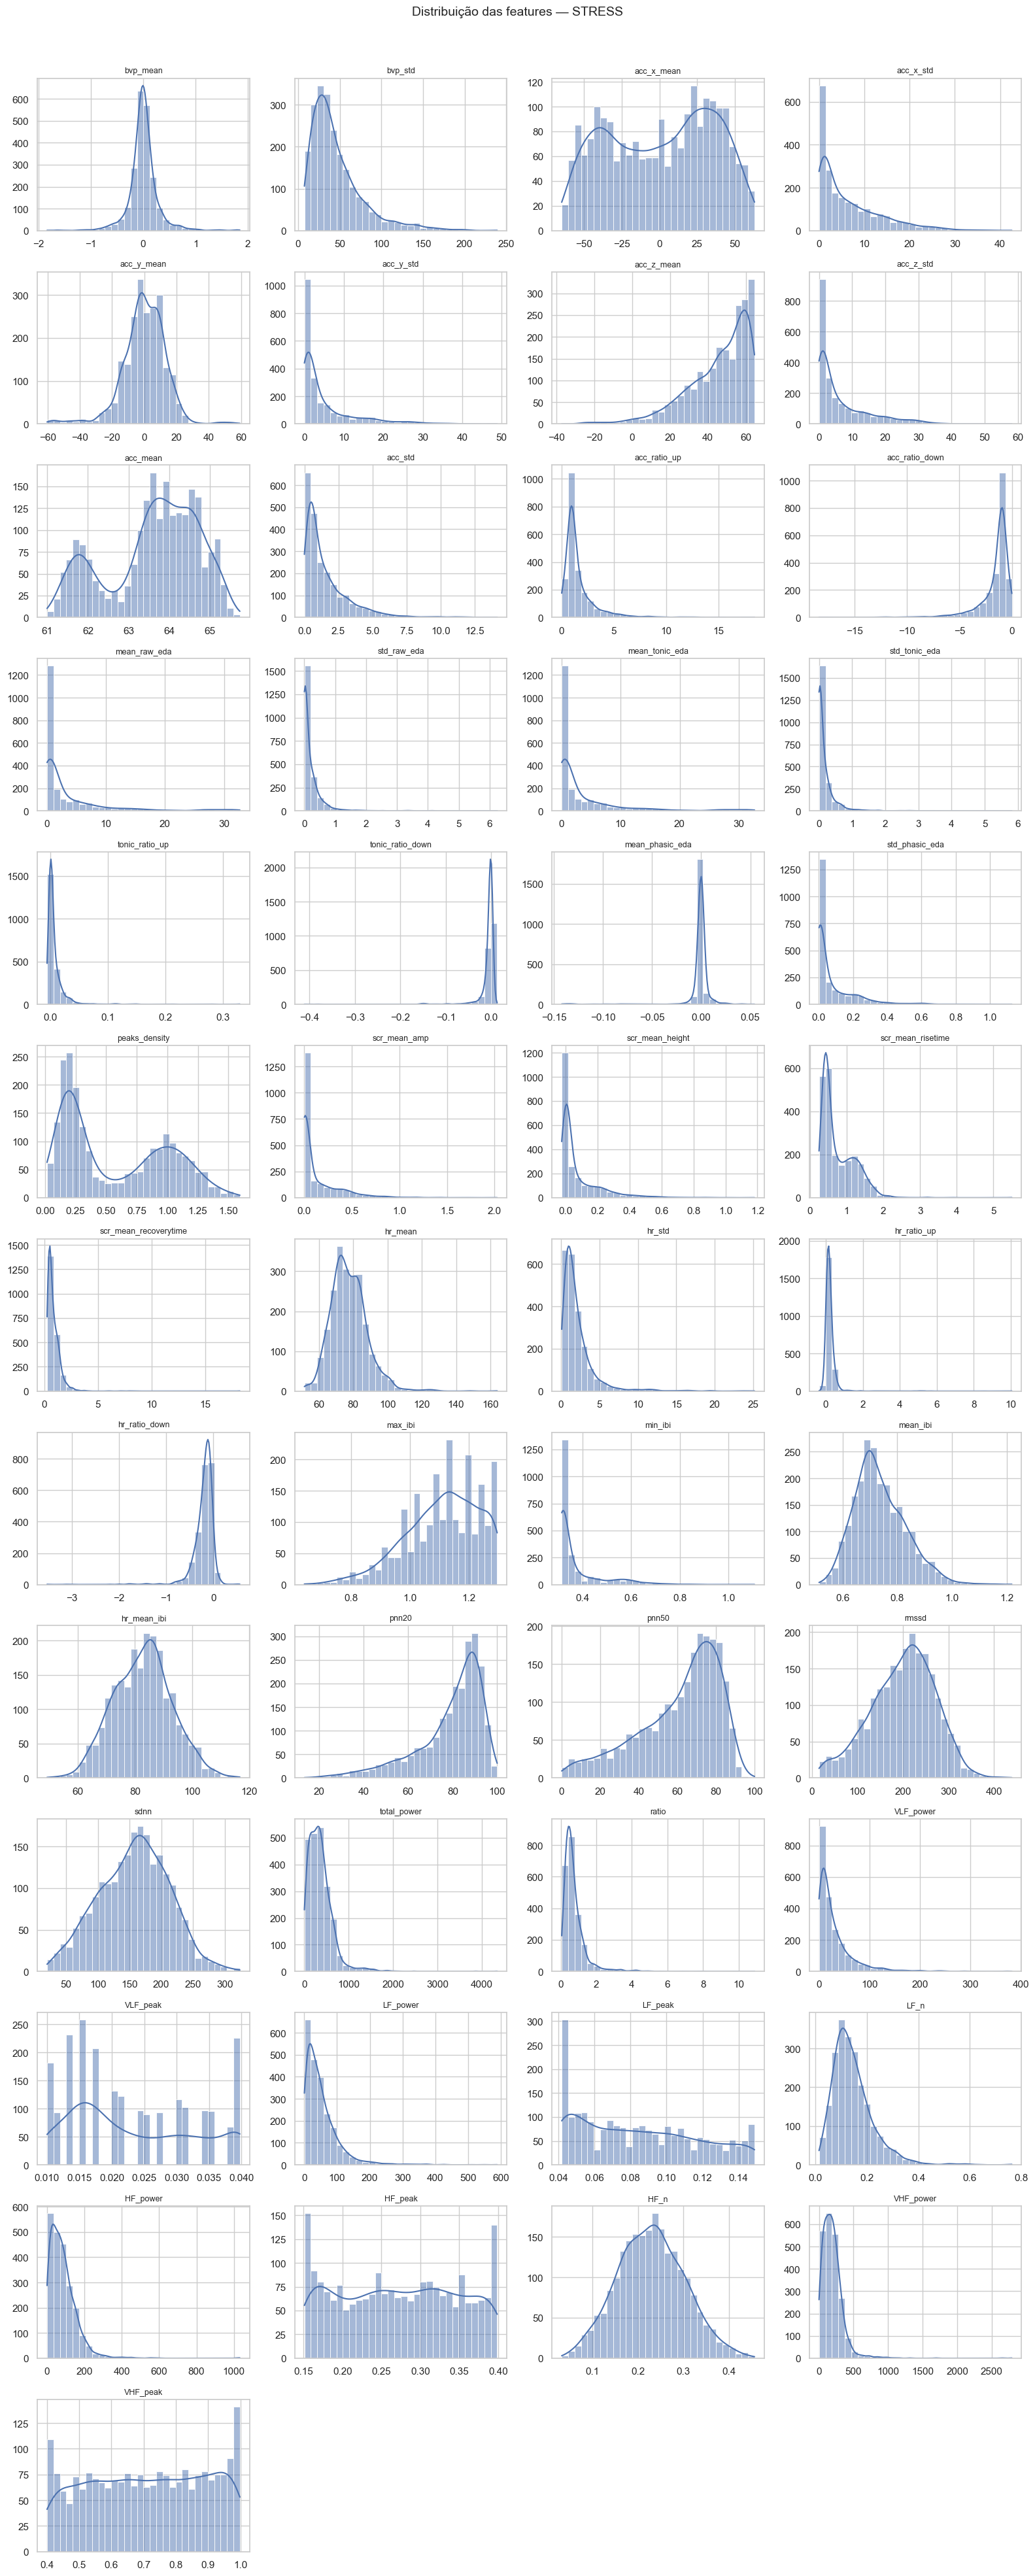

In [ ]:
df_plot = datasets['stress']
feat_cols = [c for c in df_plot.columns if c not in META_COLS]

n_cols = 4
n_rows = (len(feat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    if df_plot[col].std() == 0:
        ax.text(0.5, 0.5, f'Constante\n({col})', ha='center', va='center')
        ax.set_title(col, fontsize=9)
        continue
    sns.histplot(data=df_plot, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das features para STRESS", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Compara a distribuição de cada feature entre as classes.
As Features onde as caixas (IQR) não se sobrepõem entre labels são candidatas a ter alta importância no modelo e as features com sobreposição total têm pouco poder discriminativo individual.

<ipython-input-6-9d41d7d6e69f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='label', y=col, ax=ax,
<ipython-input-6-9d41d7d6e69f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='label', y=col, ax=ax,
<ipython-input-6-9d41d7d6e69f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='label', y=col, ax=ax,
<ipython-input-6-9d41d7d6e69f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

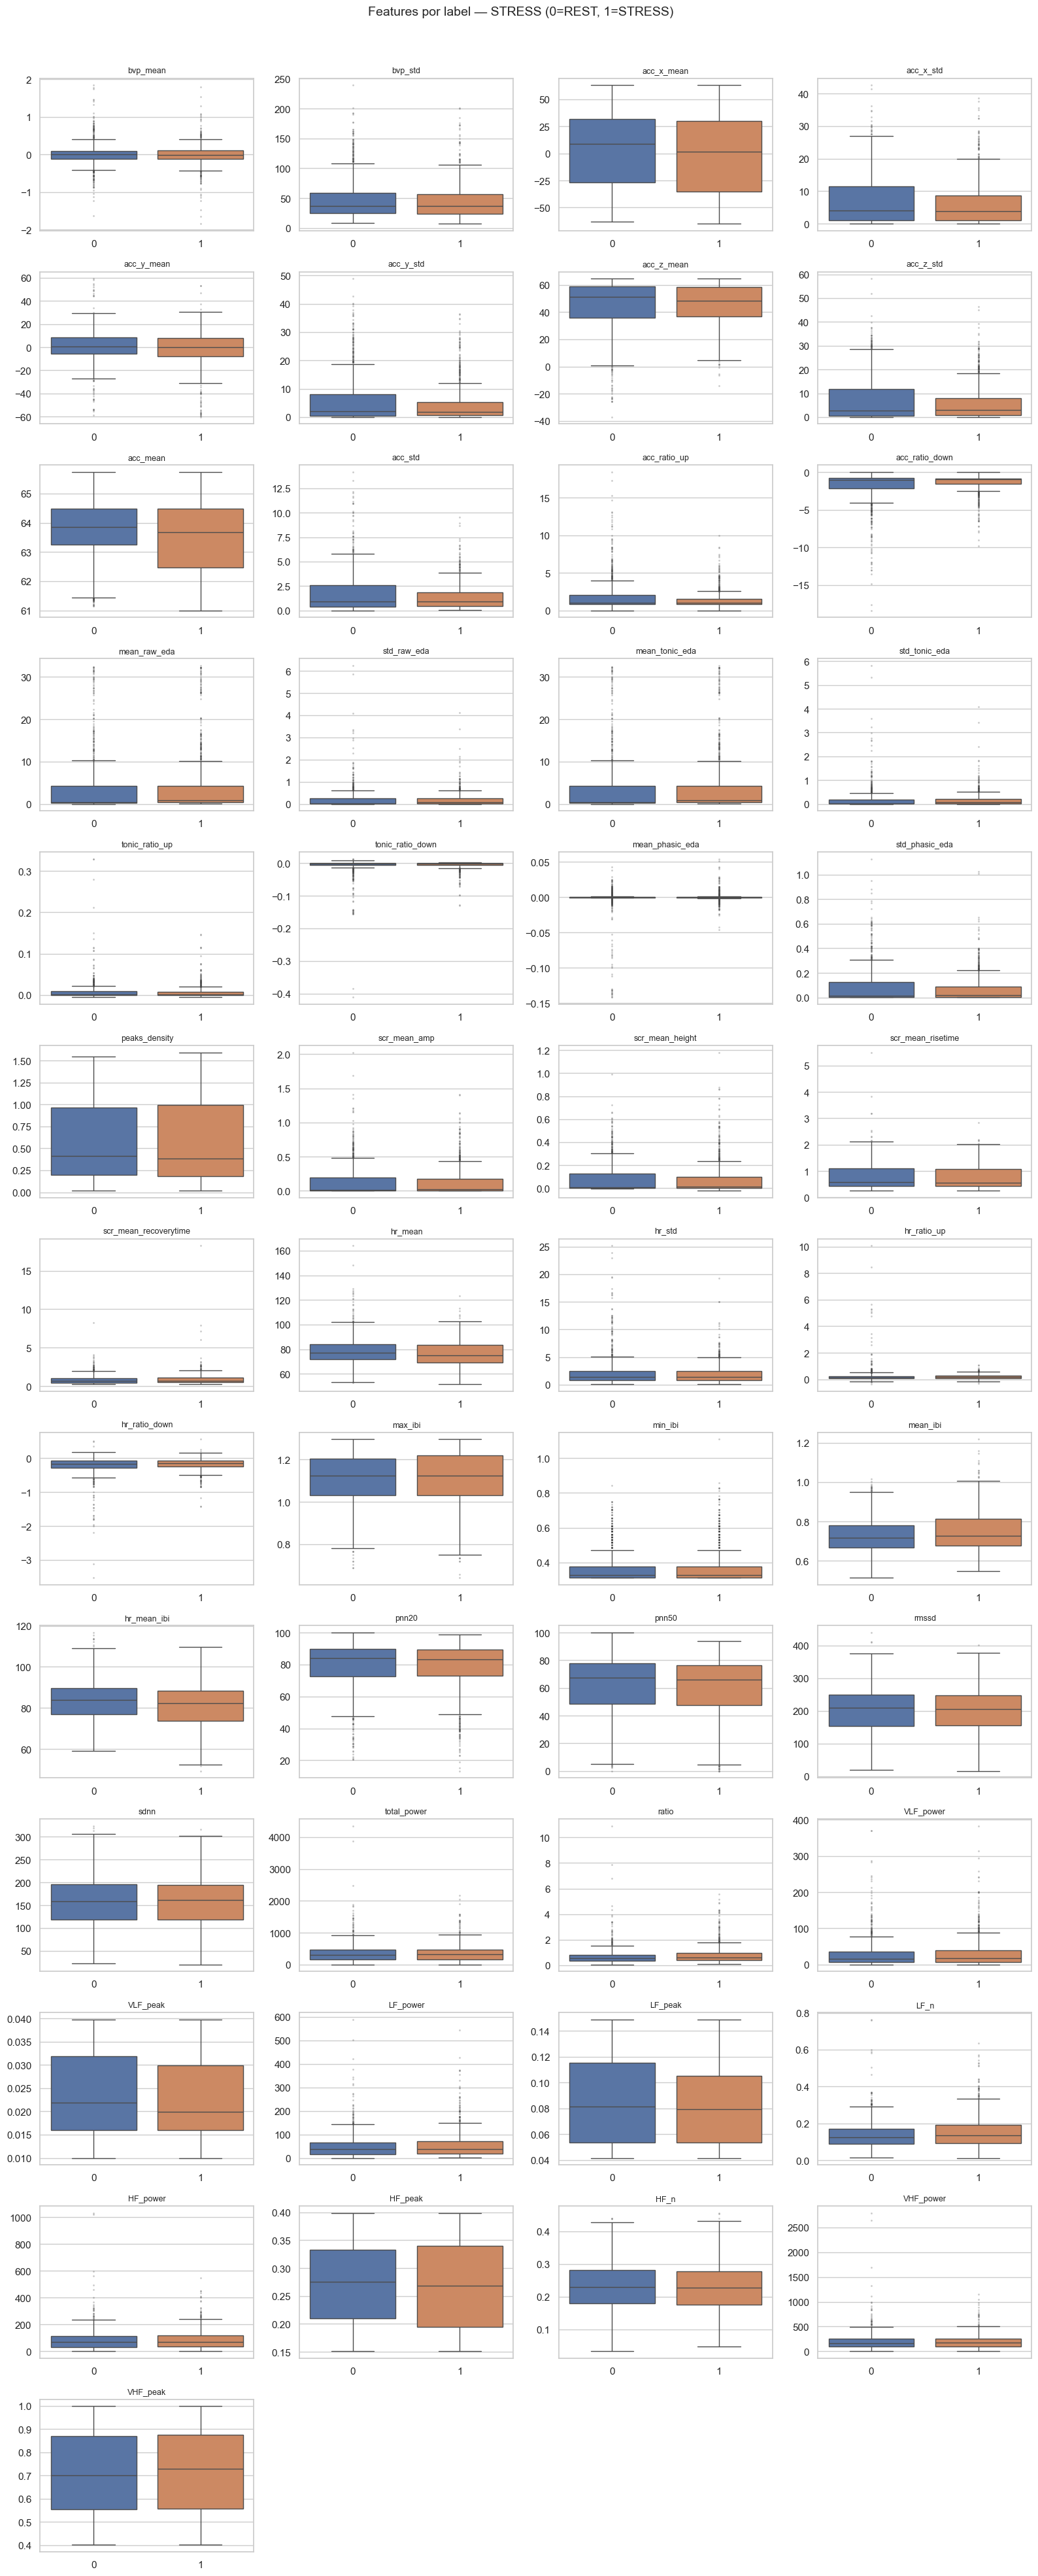

In [ ]:
df_plot = datasets['stress']
feat_cols = [c for c in df_plot.columns if c not in META_COLS]

n_cols = 4
n_rows = (len(feat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    if df_plot[col].std() == 0:
        ax.set_visible(False)
        continue
    sns.boxplot(data=df_plot, x='label', y=col, ax=ax,
                palette=['#4C72B0', '#DD8452'],
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Features por label — STRESS (0=REST, 1=STRESS)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Identifica features altamente correlacionadas |r| > 0.9, que podem ser redundantes. 

Features redundantes inflam a importância relativa em modelos baseados em árvore e podem ser candidatas a remoção ou agrupamento.

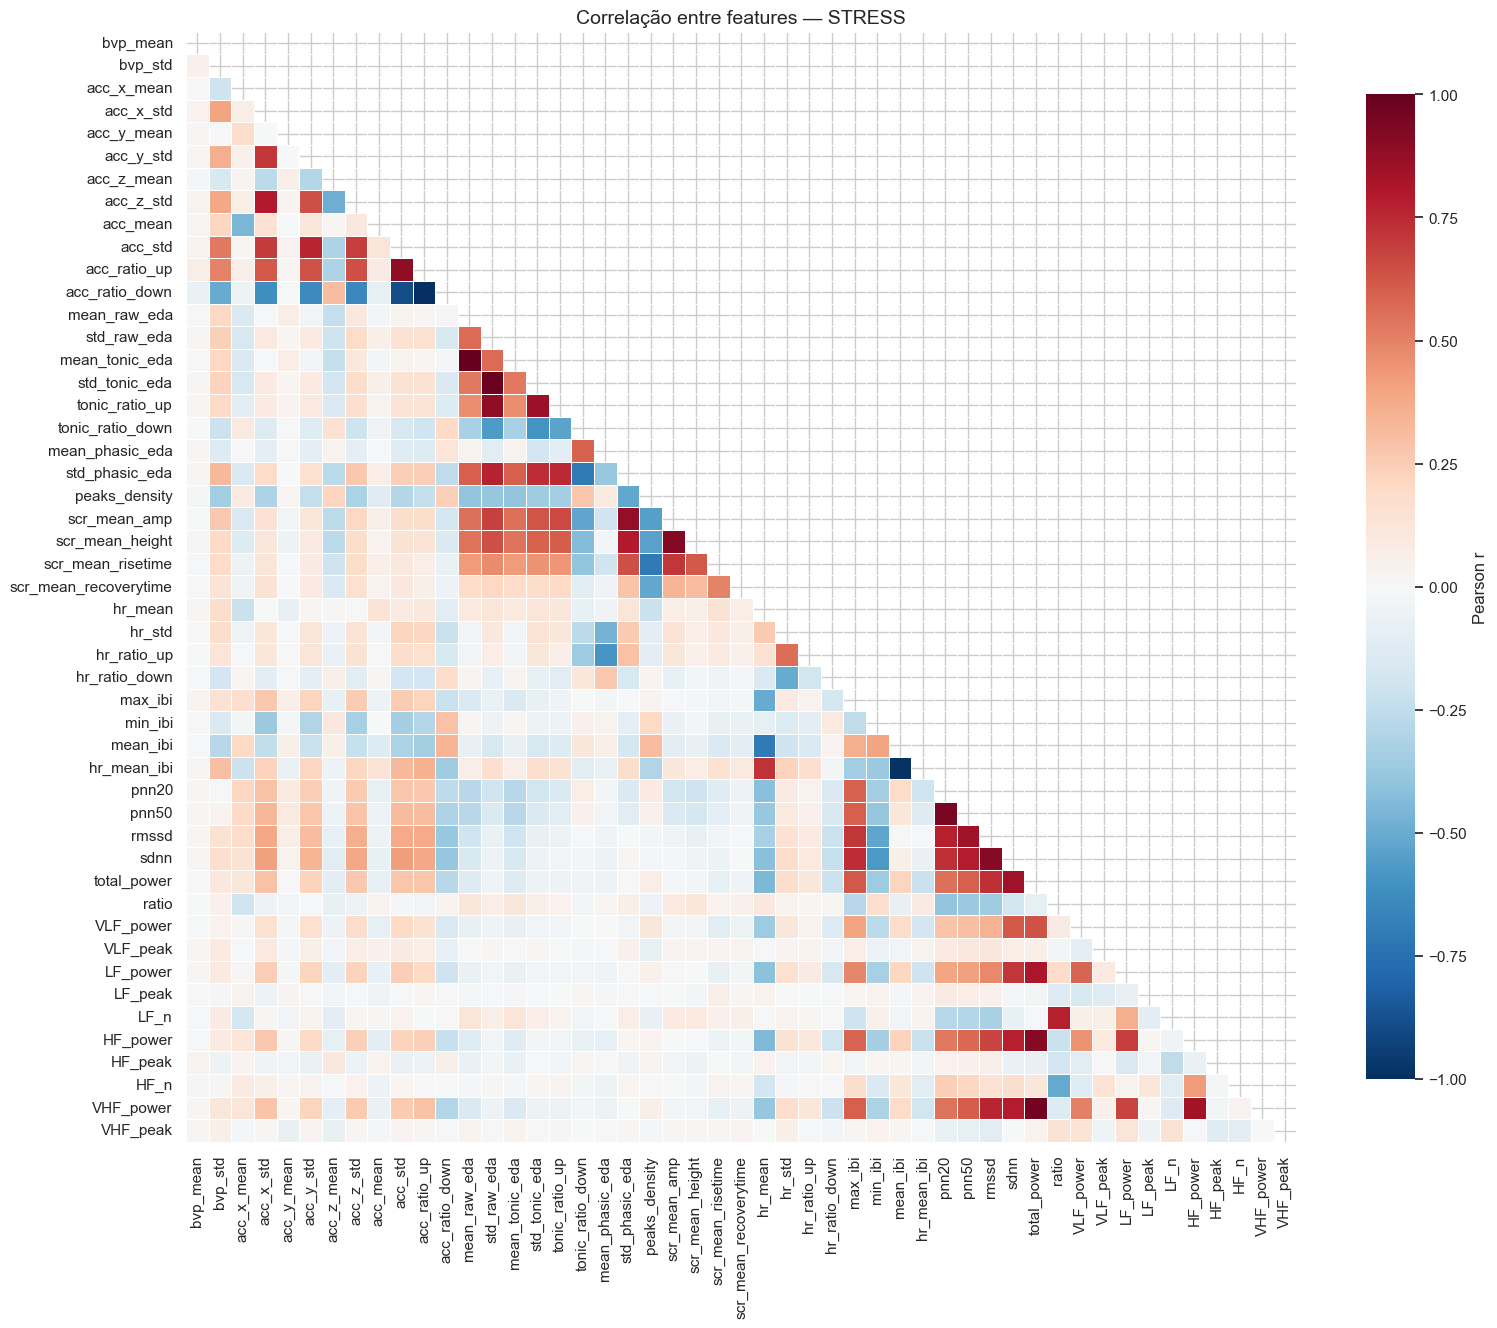

Pares com |r| > 0.9:
  mean_raw_eda × mean_tonic_eda: r=1.0
  acc_ratio_up × acc_ratio_down: r=-0.996
  std_raw_eda × std_tonic_eda: r=0.988
  mean_ibi × hr_mean_ibi: r=-0.985
  total_power × VHF_power: r=0.961
  pnn20 × pnn50: r=0.952
  scr_mean_amp × scr_mean_height: r=0.918
  rmssd × sdnn: r=0.908
  total_power × HF_power: r=0.907


In [ ]:
df_plot = datasets['stress']
feat_cols = [c for c in df_plot.columns if c not in META_COLS]

corr = df_plot[feat_cols].corr()

# Heatmap completo
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Correlação entre features — STRESS", fontsize=14)
plt.tight_layout()
plt.show()

# Pares com alta correlação
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr:
    print("Pares com |r| > 0.9:")
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} × {f2}: r={r}")
else:
    print("Nenhum par com |r| > 0.9")

Consolida as observações do EDA para referência rápida.

In [ ]:
for name, df in datasets.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    label_counts = df['label'].value_counts()
    ratio = label_counts.min() / label_counts.max()
    
    print(f"{name.upper()}")
    print(f"  - Janelas: {len(df)} | Sujeitos: {df['subject_id'].nunique()}")
    print(f"  - Classe majoritária: {label_counts.idxmax()} ({label_counts.max()})")
    print(f"  - Classe minoritária: {label_counts.idxmin()} ({label_counts.min()})")
    print(f"  - Razão min/max: {ratio:.3f}")
    print(f"  - Janelas/sujeito: min={df.groupby('subject_id').size().min()}, "
          f"max={df.groupby('subject_id').size().max()}, "
          f"média={df.groupby('subject_id').size().mean():.1f}")
    print()

=== STRESS ===
  Janelas: 2210 | Sujeitos: 31
  Classe majoritária: 0 (1161)
  Classe minoritária: 1 (1049)
  Razão min/max: 0.904
  Janelas/sujeito: min=39, max=143, média=71.3

=== ANAEROBIC ===
  Janelas: 1544 | Sujeitos: 29
  Classe majoritária: 0 (1455)
  Classe minoritária: 1 (89)
  Razão min/max: 0.061
  Janelas/sujeito: min=35, max=96, média=53.2

=== AEROBIC ===
  Janelas: 1967 | Sujeitos: 27
  Classe majoritária: 1 (1190)
  Classe minoritária: 0 (777)
  Razão min/max: 0.653
  Janelas/sujeito: min=56, max=101, média=72.9

